# Conduct an Exploratory Data Analysis (EDA) on the dataset. Highlight the main insights and any irregularities you find, and address those anomalies appropriately!

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [20]:
df=pd.read_csv('Bangladesh_Crime_Dataset_A.csv')

In [21]:
df.head()

,Unnamed: 0,incident_month,incident_week,incident_weekday,weekend,part_of_the_day,incident_district,incident_division,precip,visibility,...,average_household_size,density_per_kmsq,literacy_rate,religious_institution,playground,park,police_station,school,college,crime
0,0,7.0,29,wednesday,0,morning,dhaka,dhaka,6.1,10,...,8.42,30551.0,74.6,4289,99,17,60,242,64,murder
1,1,1.0,2,wednesday,0,night,dhaka,dhaka,0.0,10,...,8.42,30551.0,74.6,4289,99,17,60,242,64,murder
2,2,1.0,4,tuesday,0,night,dhaka,dhaka,0.0,10,...,8.42,30551.0,74.6,4289,99,17,60,242,64,murder
3,3,3.0,9,friday,1,night,dhaka,dhaka,0.0,10,...,8.42,30551.0,74.6,4289,99,17,60,242,64,murder
4,4,8.0,34,thursday,0,night,dhaka,dhaka,21.9,9,...,8.42,30551.0,74.6,4289,99,17,60,242,64,murder


In [22]:
# 1. Menghapus kolom index yang tidak perlu
df.drop(columns=['Unnamed: 0'], inplace=True, errors='ignore')

In [23]:
# 2. Standarisasi teks (kecilkan huruf dan hapus spasi yang berlebihan)
cat_cols = ['incident_weekday', 'part_of_the_day', 'incident_district', 'incident_division', 'season', 'crime']
for col in cat_cols:
    df[col] = df[col].astype(str).str.strip().str.lower()

In [24]:
# 3. Menangani Anomali Kepadatan Penduduk (density_per_kmsq)
# Mengganti nilai ekstrem (outliers) dengan nilai median
median_density = df.loc[df['density_per_kmsq'] < 100000, 'density_per_kmsq'].median()
df.loc[df['density_per_kmsq'] > 100000, 'density_per_kmsq'] = median_density

In [25]:
# 4. Memperbaiki Missing Values pada Bulan (incident_month)
# Jika bulan kosong, di isi berdasarkan minggu ke berapa kejadian tersebut
def week_to_month(week):
    month = int(np.ceil(week / 4.345))
    return min(12, max(1, month))

df['incident_month'] = df.apply(
    lambda row: week_to_month(row['incident_week']) if pd.isna(row['incident_month']) else row['incident_month'],
    axis=1
)


In [26]:
# 5. Memperbaiki nilai negatif pada kantor polisi
df.loc[df['police_station'] < 0, 'police_station'] = 0

In [27]:
# 6. Mengisi data yang hilang lainnya
df['literacy_rate'] = df.groupby('incident_division')['literacy_rate'].transform(lambda x: x.fillna(x.median()))
df['part_of_the_day'] = df['part_of_the_day'].replace('nan', df['part_of_the_day'].mode()[0])
df['incident_district'] = df['incident_district'].replace('nan', 'unknown')

In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6574 entries, 0 to 6573
Data columns (total 25 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   incident_month          6574 non-null   float64
 1   incident_week           6574 non-null   int64  
 2   incident_weekday        6574 non-null   object 
 3   weekend                 6574 non-null   int64  
 4   part_of_the_day         6574 non-null   object 
 5   incident_district       6574 non-null   object 
 6   incident_division       6574 non-null   object 
 7   precip                  6574 non-null   float64
 8   visibility              6574 non-null   int64  
 9   heatindex               6574 non-null   int64  
 10  season                  6574 non-null   object 
 11  male_population         6574 non-null   int64  
 12  female_population       6574 non-null   int64  
 13  total_population        6574 non-null   int64  
 14  gender_ration           6574 non-null   

Dataset mengandung beberapa ketidakwajaran data, terutama pada kolom numerik dan kategorikal. Nilai kepadatan penduduk (density_per_kmsq) menunjukkan outliers ekstrem (lebih dari 100.000), yang berpotensi mendistorsi analisis. anomali ini ditangani dengan menggantinya menggunakan nilai median dari distribusi yang masih masuk akal. Pada kolom incident_month, terdapat missing values yang kemudian diestimasi secara logis berdasarkan incident_week, sehingga informasi waktu kejadian tetap konsisten. Selain itu, ditemukan nilai negatif pada jumlah kantor polisi (police_station) yang secara logis tidak mungkin, sehingga diperbaiki dengan menetapkannya ke nilai minimum 0. Beberapa variabel kategorikal juga mengandung nilai kosong atau tidak konsisten (misalnya “nan” dalam bentuk string), yang kemudian distandarisasi menggunakan modus atau label “unknown”. Untuk literacy_rate, nilai hilang diimputasi menggunakan median per incident_division agar tetap mencerminkan karakteristik wilayah.

Main Insights:
Data menunjukkan bahwa kualitas dataset meningkat signifikan setelah pembersihan, dengan variabel waktu, lokasi, dan kondisi sosial menjadi lebih konsisten dan siap untuk analisis lanjutan.

In [29]:
# 11. SAVE CLEAN DATA
df.to_csv("Cleaned_Bangladesh_Crime_Dataset.csv", index=False)
print("\nCleaned dataset saved as Cleaned_Bangladesh_Crime_Dataset.csv")


Cleaned dataset saved as Cleaned_Bangladesh_Crime_Dataset.csv


# Train K-Means and tune it based on a minimum of two metrics. Afterward, visualize the final clusters!

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# 1. Load data hasil cleaning sebelumnya
df = pd.read_csv('Cleaned_Bangladesh_Crime_Dataset.csv')

In [31]:
# 2. Pilih fitur untuk clustering
features = [
    'precip', 'visibility', 'heatindex', 'total_population',
    'gender_ration', 'average_household_size', 'density_per_kmsq',
    'literacy_rate', 'religious_institution', 'playground',
    'park', 'police_station', 'school', 'college'
]
X = df[features]

In [32]:
# 3. Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

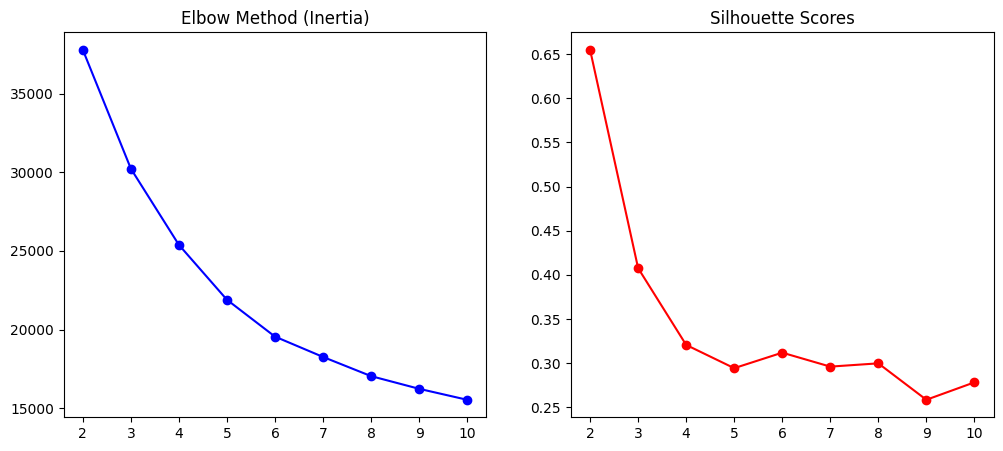

In [33]:
# 4. Mencari K terbaik (Tuning)
inertia = []
silhouette_scores = []
k_range = range(2, 11)

for k in k_range:
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = model.fit_predict(X_scaled)
    inertia.append(model.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, labels))

# Plotting Metrik Tuning
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(k_range, inertia, 'bo-')
plt.title('Elbow Method (Inertia)')
plt.subplot(1, 2, 2)
plt.plot(k_range, silhouette_scores, 'ro-')
plt.title('Silhouette Scores')
plt.show()

In [34]:
# 5. Melatih Model dengan K=2
optimal_k = 2
final_kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df['cluster'] = final_kmeans.fit_predict(X_scaled)

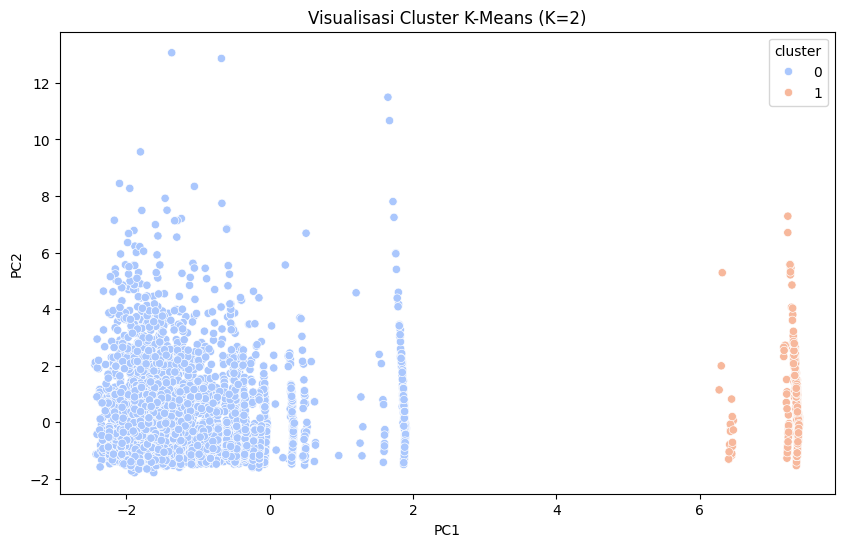

In [35]:
# 6. Visualisasi dengan PCA (Mengubah banyak kolom jadi 2 dimensi)
pca = PCA(n_components=2)
pca_data = pca.fit_transform(X_scaled)
df_pca = pd.DataFrame(pca_data, columns=['PC1', 'PC2'])
df_pca['cluster'] = df['cluster']

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_pca, x='PC1', y='PC2', hue='cluster', palette='coolwarm')
plt.title(f'Visualisasi Cluster K-Means (K={optimal_k})')
plt.show()

Berdasarkan visualisasi yang ditampilkan, pemilihan jumlah cluster K = 2 di dapat dari dua pendekatan evaluasi. Pada Elbow Method, penurunan nilai inertia terlihat sangat tajam dari K=2 ke K=3, kemudian mulai melandai setelahnya, yang mengindikasikan bahwa penambahan cluster di atas K=2 hanya memberikan perbaikan kecil terhadap homogenitas cluster. Sementara itu, Silhouette Score mencapai nilai tertinggi pada K=2, menunjukkan bahwa pemisahan antar cluster paling jelas dan anggota dalam setiap cluster relatif kompak dibandingkan pilihan K lainnya.

Visualisasi hasil K-Means (K=2) pada ruang PCA (PC1 dan PC2) juga memperlihatkan dua kelompok yang terpisah cukup jelas, di mana satu cluster mendominasi mayoritas data dan cluster lainnya membentuk kelompok yang lebih kecil namun terdefinisi dengan baik. Secara keseluruhan, kombinasi metrik kuantitatif dan visual ini menunjukkan bahwa dua cluster merupakan jumlah yang paling optimal dan representatif untuk menggambarkan struktur data.

# profile each cluster to understand its customer characteristics

In [36]:
# 7. Melihat karakteristik rata-rata tiap cluster
profile = df.groupby('cluster')[features].mean()
print("--- Karakteristik Tiap Cluster ---")
print(profile)

--- Karakteristik Tiap Cluster ---
           precip  visibility  heatindex  total_population  gender_ration  \
cluster                                                                     
0        6.353122    9.476324  31.533848      5.381571e+05     101.283935   
1        5.108257    9.566514  32.014908      8.906039e+06     125.000000   

         average_household_size  density_per_kmsq  literacy_rate  \
cluster                                                            
0                      4.436657       2620.826793      52.901263   
1                      8.420000      29898.071101      74.312385   

         religious_institution  playground       park  police_station  \
cluster                                                                 
0                   764.533146   33.864609   1.854788        4.395826   
1                  4289.000000   99.000000  17.000000       59.931193   

             school    college  
cluster                         
0         49.713259   8.

In [37]:
# 8. Melihat persebaran jenis kejahatan di tiap cluster
crime_dist = pd.crosstab(df['cluster'], df['crime'], normalize='index') * 100
print("\n--- Persentase Jenis Kejahatan per Cluster ---")
print(crime_dist)


--- Persentase Jenis Kejahatan per Cluster ---
crime      assault  bodyfound     kidnap     murder       rape    robbery
cluster                                                                  
0        16.485444  22.483339  10.242020  24.324798  18.765345   7.699053
1        18.004587  26.949541   7.683486  15.022936  14.105505  18.233945


Cluster 0 merepresentasikan wilayah dengan skala populasi relatif kecil, kepadatan penduduk rendah - menengah, serta tingkat literasi yang lebih rendah. Ukuran rumah tangga cenderung lebih kecil dan jumlah fasilitas publik seperti sekolah, perguruan tinggi, taman, serta kantor polisi juga terbatas. Dari sisi kriminalitas, cluster ini didominasi oleh kidnap, bodyfound, dan murder, dengan proporsi robbery yang relatif rendah.

Sebaliknya, Cluster 1 menggambarkan wilayah dengan populasi dan kepadatan sangat tinggi, ukuran rumah tangga besar, serta literacy rate yang lebih tinggi. Infrastruktur publik jauh lebih lengkap, terlihat dari tingginya jumlah sekolah, perguruan tinggi, taman, dan kantor polisi. Pada cluster ini, jenis kejahatan yang menonjol adalah bodyfound dan robbery, sementara rape dan kidnap relatif lebih rendah dibanding cluster 0.
